This code calculates the percentage of Y2Y covered in grasslands using CEC 2020 data

## Load packages and initialize GEE

In [11]:
# import packages
import ee
import geemap
import pandas as pd

In [12]:
# authenticate the EE api
ee.Authenticate()

True

In [13]:
# initialize the EE api
ee.Initialize(project='y2y-climate-benefits')

## Define GEE datasets

In [14]:
# define EE datasets
# landcover
lc = ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS")

# vector
y2y = ee.FeatureCollection("projects/y2y-climate-benefits/assets/inputs/y2y")

## Calculate total Y2Y area

In [15]:
# Calculate total area of the Y2Y boundary using pixel area
# pixelArea() returns m² per pixel; sum over the geometry then convert to km²
y2y_geom = y2y.geometry()

total_area_m2 = (
    ee.Image.pixelArea()
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=y2y_geom,
        scale=30,
        maxPixels=1e13,
        bestEffort=True,
    )
    .getInfo()['area']
)

total_area_km2 = total_area_m2 / 1e6
print(f'Total Y2Y area: {total_area_km2:>15,.0f} km²')

Total Y2Y area:       1,369,949 km²


## Define NALCMS land cover classes

The NALCMS 2020 dataset uses 19 land cover classes. Grassland in the Y2Y region is represented by:
- **Class 10**: Temperate or sub-polar grassland
- **Class 12**: Sub-polar or polar grassland-lichen-moss

In [16]:
# NALCMS 2020 class definitions — tropical classes excluded (not present in Y2Y)
# Colors sourced from GEE catalog:
# https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2020_REL_NALCMS
NALCMS_CLASSES = {
     1: ('Temperate or sub-polar needleleaf forest',          '#033e00'),
     2: ('Sub-polar taiga needleleaf forest',                 '#939b71'),
     5: ('Temperate or sub-polar broadleaf deciduous forest', '#5b725c'),
     6: ('Mixed forest',                                      '#6b7d2c'),
     8: ('Temperate or sub-polar shrubland',                  '#b48833'),
    10: ('Temperate or sub-polar grassland',                  '#e0cd88'),
    11: ('Sub-polar or polar shrubland-lichen-moss',          '#a07451'),
    12: ('Sub-polar or polar grassland-lichen-moss',          '#bad292'),
    13: ('Sub-polar or polar barren-lichen-moss',             '#3f8970'),
    14: ('Wetland',                                           '#6ca289'),
    15: ('Cropland',                                          '#e6ad6a'),
    16: ('Barren lands',                                      '#a9abae'),
    17: ('Urban and built-up',                                '#db2126'),
    18: ('Water',                                             '#4c73a1'),
    19: ('Snow and ice',                                      '#fff7fe'),
}

# Grassland classes relevant to Y2Y
GRASSLAND_CLASSES = [10, 12]  # temperate grassland + sub-polar grassland-lichen-moss

print('Grassland classes:')
for v in GRASSLAND_CLASSES:
    print(f'  Class {v}: {NALCMS_CLASSES[v][0]}')

Grassland classes:
  Class 10: Temperate or sub-polar grassland
  Class 12: Sub-polar or polar grassland-lichen-moss


## Calculate grassland area

In [17]:
# Clip the NALCMS image to Y2Y and select the landcover band
lc_y2y = lc.select('landcover').clipToCollection(y2y)

# Calculate area per NALCMS class using grouped reducer
lc_with_area = ee.Image.pixelArea().rename('area').addBands(lc_y2y)

stats = lc_with_area.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='lc_class'),
    geometry=y2y_geom,
    scale=30,
    maxPixels=1e13,
    bestEffort=True,
)

groups = stats.get('groups').getInfo()

# Build results dataframe
rows = []
for g in groups:
    cls = int(g['lc_class'])
    area_km2 = g['sum'] / 1e6
    rows.append({
        'class_value': cls,
        'class_name':  NALCMS_CLASSES.get(cls, (f'Class {cls}', '#aaaaaa'))[0],
        'area_km2':    area_km2,
    })

df = pd.DataFrame(rows).sort_values('class_value').reset_index(drop=True)
df['area_pct'] = df['area_km2'] / total_area_km2 * 100

print(df.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))

 class_value                                        class_name  area_km2  area_pct
           1          Temperate or sub-polar needleleaf forest 643,016.5      46.9
           2                 Sub-polar taiga needleleaf forest   2,509.6       0.2
           5 Temperate or sub-polar broadleaf deciduous forest  10,065.1       0.7
           6                                      Mixed forest  58,117.0       4.2
           8                  Temperate or sub-polar shrubland 249,879.9      18.2
          10                  Temperate or sub-polar grassland 135,055.2       9.9
          11          Sub-polar or polar shrubland-lichen-moss   1,414.9       0.1
          12          Sub-polar or polar grassland-lichen-moss     228.1       0.0
          14                                           Wetland  49,163.9       3.6
          15                                          Cropland  21,141.9       1.5
          16                                      Barren lands 158,310.4      11.6
    

In [18]:
# Summarise grassland totals
grassland_df = df[df['class_value'].isin(GRASSLAND_CLASSES)]
grassland_km2 = grassland_df['area_km2'].sum()
grassland_pct = grassland_km2 / total_area_km2 * 100

print('=== Grassland Area Summary ===')
print()
for _, row in grassland_df.iterrows():
    print(f"  Class {int(row['class_value']):2d} ({row['class_name']})")
    print(f"    Area: {row['area_km2']:>12,.0f} km²  ({row['area_pct']:.2f}% of Y2Y)")
print()
print(f'  Total Y2Y area:         {total_area_km2:>12,.0f} km²')
print(f'  Total grassland area:   {grassland_km2:>12,.0f} km²')
print(f'  Grassland cover:        {grassland_pct:>11.2f}%')

=== Grassland Area Summary ===

  Class 10 (Temperate or sub-polar grassland)
    Area:      135,055 km²  (9.86% of Y2Y)
  Class 12 (Sub-polar or polar grassland-lichen-moss)
    Area:          228 km²  (0.02% of Y2Y)

  Total Y2Y area:            1,369,949 km²
  Total grassland area:        135,283 km²
  Grassland cover:               9.88%


## Generate Y2Y land cover maps

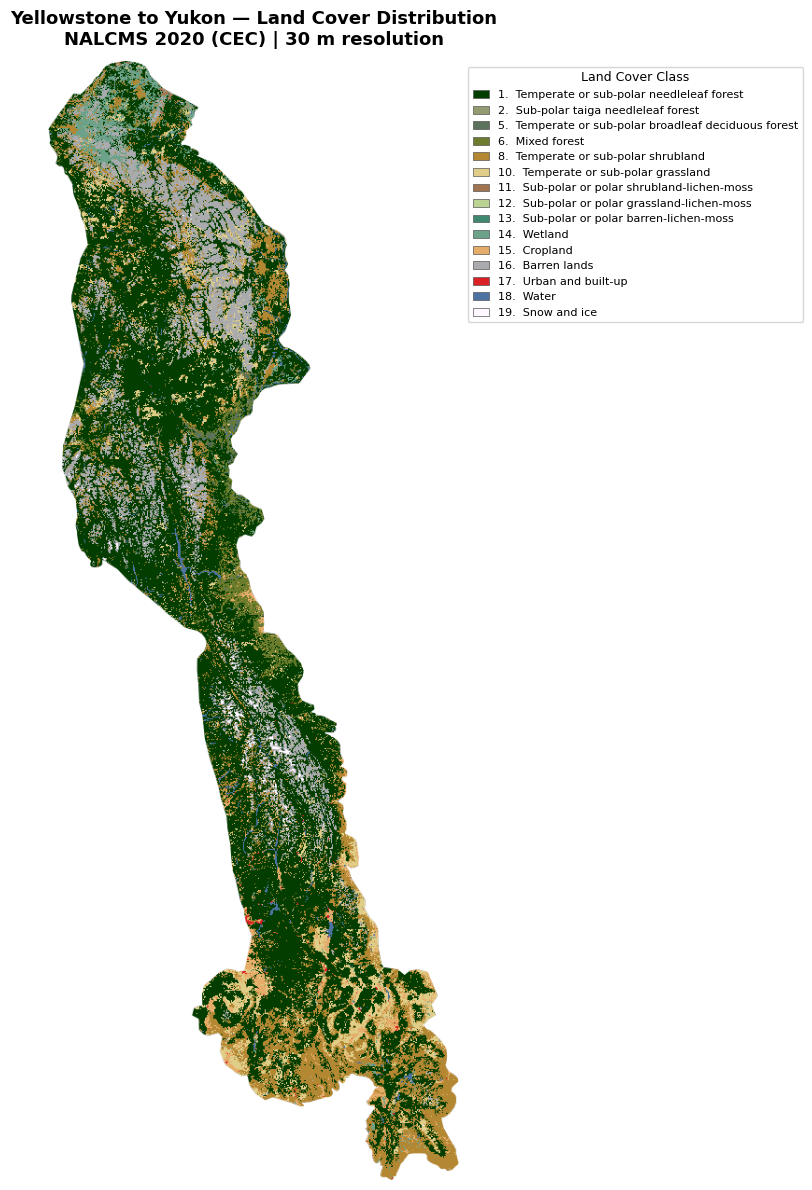

In [19]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Full 19-class palette (tropical classes included for correct GEE palette
# indexing — they won't appear in Y2Y data so colors don't matter)
FULL_PALETTE = {
     1: '#033e00',  2: '#939b71',  3: '#196d12',  4: '#1fab01',
     5: '#5b725c',  6: '#6b7d2c',  7: '#b29d29',  8: '#b48833',
     9: '#e9da5d', 10: '#e0cd88', 11: '#a07451', 12: '#bad292',
    13: '#3f8970', 14: '#6ca289', 15: '#e6ad6a', 16: '#a9abae',
    17: '#db2126', 18: '#4c73a1', 19: '#fff7fe',
}
full_palette_list = [FULL_PALETTE[i] for i in range(1, 20)]

thumb_url_lc = lc_y2y.getThumbURL({
    'min': 1,
    'max': 19,
    'palette': full_palette_list,
    'dimensions': 1200,
    'region': y2y_geom,
    'format': 'png',
})
lc_map_img = Image.open(BytesIO(requests.get(thumb_url_lc).content))

fig_lc, ax_lc = plt.subplots(figsize=(8, 12))
ax_lc.imshow(lc_map_img)
ax_lc.axis('off')
ax_lc.set_title(
    'Yellowstone to Yukon — Land Cover Distribution\nNALCMS 2020 (CEC) | 30 m resolution',
    fontsize=13, fontweight='bold', pad=12
)

# Legend shows only non-tropical classes present in Y2Y
legend_elements_lc = [
    Patch(facecolor=NALCMS_CLASSES[v][1], edgecolor='#555555', linewidth=0.5,
          label=f'{v}.  {NALCMS_CLASSES[v][0]}')
    for v in sorted(NALCMS_CLASSES)
]
ax_lc.legend(
    handles=legend_elements_lc,
    loc='upper left', bbox_to_anchor=(1.01, 1),
    fontsize=8, frameon=True,
    title='Land Cover Class', title_fontsize=9,
    handlelength=1.5,
)

plt.tight_layout()
plt.show()

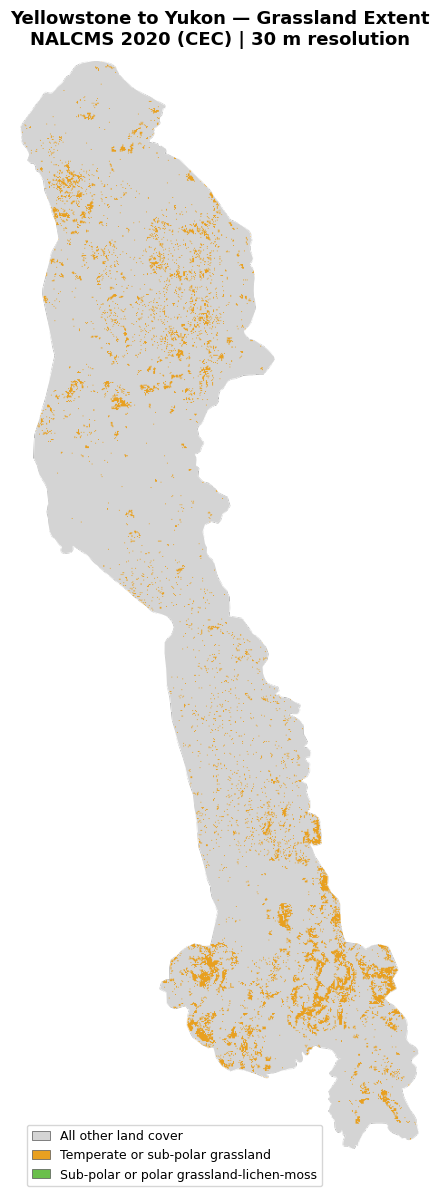

In [20]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Remap all classes to 3 values:
#   0 = all other LC  (light grey)
#   1 = class 10 — Temperate or sub-polar grassland   (vivid amber)
#   2 = class 12 — Sub-polar or polar grassland-lichen-moss  (vivid lime-green)
all_classes  = list(range(1, 20))
remap_to     = [0 if v not in GRASSLAND_CLASSES else (1 if v == 10 else 2)
                for v in all_classes]

grassland_img = lc_y2y.remap(all_classes, remap_to).rename('grassland')

HIGHLIGHT_COLORS = {
    0: ('#d4d4d4', 'All other land cover'),
    1: ('#e8a020', NALCMS_CLASSES[10][0]),
    2: ('#6abf4b', NALCMS_CLASSES[12][0]),
}

thumb_url = grassland_img.getThumbURL({
    'min': 0,
    'max': 2,
    'palette': [HIGHLIGHT_COLORS[i][0] for i in range(3)],
    'dimensions': 1200,
    'region': y2y_geom,
    'format': 'png',
})

map_img = Image.open(BytesIO(requests.get(thumb_url).content))

fig_map, ax_map = plt.subplots(figsize=(8, 12))
ax_map.imshow(map_img)
ax_map.axis('off')
ax_map.set_title(
    'Yellowstone to Yukon — Grassland Extent\nNALCMS 2020 (CEC) | 30 m resolution',
    fontsize=13, fontweight='bold', pad=12
)

legend_elements = [
    Patch(facecolor=color, edgecolor='#555555', linewidth=0.5, label=label)
    for color, label in HIGHLIGHT_COLORS.values()
]
ax_map.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0, -0.04),
    fontsize=9,
    frameon=True,
    ncol=1,
    handlelength=1.5,
)

plt.tight_layout()
plt.show()

In [21]:
import os
from matplotlib.backends.backend_pdf import PdfPages

output_dir = 'grassland_extent_y2y'
os.makedirs(output_dir, exist_ok=True)
output_path = f'{output_dir}/grassland_extent_y2y_nalcms2020.pdf'

# ── Page 1: LC area table ─────────────────────────────────────────────────────
display_df = df[['class_value', 'class_name', 'area_km2', 'area_pct']].copy()
display_df = display_df[display_df['class_value'].isin(NALCMS_CLASSES)]
display_df['area_km2_fmt'] = display_df['area_km2'].apply(lambda x: f'{x:,.0f}')
display_df['area_pct_fmt'] = display_df['area_pct'].apply(lambda x: f'{x:.2f}%')

highlight_vals = set(GRASSLAND_CLASSES)
col_labels = ['Class', 'Land Cover Class', 'Area (km²)', '% of Y2Y']
col_widths  = [0.06, 0.52, 0.22, 0.12]

rows_data, row_colors = [], []
for _, r in display_df.iterrows():
    rows_data.append([
        str(int(r['class_value'])),
        r['class_name'],
        r['area_km2_fmt'],
        r['area_pct_fmt'],
    ])
    is_grass = int(r['class_value']) in highlight_vals
    row_colors.append(['#d4edda' if is_grass else 'white'] * 4)

rows_data.append(['', 'TOTAL', f'{total_area_km2:,.0f}', '100.00%'])
row_colors.append(['#e8e8e8'] * 4)

fig_height = 1.8 + len(rows_data) * 0.32
fig_table, ax_table = plt.subplots(figsize=(11, fig_height))
ax_table.axis('off')

fig_table.text(0.5, 0.98, 'Yellowstone to Yukon — Land Cover Extent',
               ha='center', va='top', fontsize=14, fontweight='bold')
fig_table.text(0.5, 0.96, 'NALCMS 2020 (CEC) | 30 m resolution',
               ha='center', va='top', fontsize=9, color='#555555')
fig_table.text(0.5, 0.94, 'Highlighted rows (green) = grassland classes used in summary',
               ha='center', va='top', fontsize=8, color='#2d6a4f', style='italic')

tbl = ax_table.table(
    cellText=rows_data, cellLoc='left',
    colLabels=col_labels, colWidths=col_widths,
    loc='center', bbox=[0, 0, 1, 1],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)

for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor('#2d6a4f')
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#cccccc')

for i, colors in enumerate(row_colors):
    for j, color in enumerate(colors):
        cell = tbl[i + 1, j]
        cell.set_facecolor(color)
        cell.set_edgecolor('#cccccc')
        if j in (0, 2, 3):
            cell.get_text().set_ha('right')
        if i == len(rows_data) - 1:
            cell.get_text().set_fontweight('bold')

fig_table.text(
    0.5, 0.01,
    f'Grassland total (classes 10 + 12):  {grassland_km2:,.0f} km²  ({grassland_pct:.2f}% of Y2Y)  |  '
    f'Total Y2Y area:  {total_area_km2:,.0f} km²',
    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2d6a4f'
)
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# ── Page 2: Full LC distribution map ─────────────────────────────────────────
thumb_url_lc = lc_y2y.getThumbURL({
    'min': 1, 'max': 19,
    'palette': full_palette_list,
    'dimensions': 1200,
    'region': y2y_geom,
    'format': 'png',
})
lc_map_img = Image.open(BytesIO(requests.get(thumb_url_lc).content))

fig_lc, ax_lc = plt.subplots(figsize=(8, 12))
ax_lc.imshow(lc_map_img)
ax_lc.axis('off')
ax_lc.set_title(
    'Yellowstone to Yukon — Land Cover Distribution\nNALCMS 2020 (CEC) | 30 m resolution',
    fontsize=13, fontweight='bold', pad=12
)
legend_elements_lc = [
    Patch(facecolor=NALCMS_CLASSES[v][1], edgecolor='#555555', linewidth=0.5,
          label=f'{v}.  {NALCMS_CLASSES[v][0]}')
    for v in sorted(NALCMS_CLASSES)
]
ax_lc.legend(
    handles=legend_elements_lc,
    loc='upper left', bbox_to_anchor=(1.01, 1),
    fontsize=8, frameon=True,
    title='Land Cover Class', title_fontsize=9,
    handlelength=1.5,
)
plt.tight_layout()

# ── Page 3: Grassland-highlighted map ────────────────────────────────────────
all_classes = list(range(1, 20))
remap_to    = [0 if v not in GRASSLAND_CLASSES else (1 if v == 10 else 2)
               for v in all_classes]
grassland_img = lc_y2y.remap(all_classes, remap_to).rename('grassland')

thumb_url_gs = grassland_img.getThumbURL({
    'min': 0, 'max': 2,
    'palette': [HIGHLIGHT_COLORS[i][0] for i in range(3)],
    'dimensions': 1200,
    'region': y2y_geom,
    'format': 'png',
})
gs_map_img = Image.open(BytesIO(requests.get(thumb_url_gs).content))

fig_map, ax_map = plt.subplots(figsize=(8, 12))
ax_map.imshow(gs_map_img)
ax_map.axis('off')
ax_map.set_title(
    'Yellowstone to Yukon — Grassland Extent\nNALCMS 2020 (CEC) | 30 m resolution',
    fontsize=13, fontweight='bold', pad=12
)
legend_elements_gs = [
    Patch(facecolor=color, edgecolor='#555555', linewidth=0.5, label=label)
    for color, label in HIGHLIGHT_COLORS.values()
]
ax_map.legend(
    handles=legend_elements_gs,
    loc='lower left', bbox_to_anchor=(0, -0.04),
    fontsize=9, frameon=True, ncol=1, handlelength=1.5,
)
plt.tight_layout()

# ── Save all three pages ──────────────────────────────────────────────────────
with PdfPages(output_path) as pdf:
    pdf.savefig(fig_table, bbox_inches='tight')
    pdf.savefig(fig_lc,    bbox_inches='tight')
    pdf.savefig(fig_map,   bbox_inches='tight')

plt.close(fig_table)
plt.close(fig_lc)
plt.close(fig_map)
print(f'Saved: {output_path}  (3 pages)')

Saved: grassland_extent_y2y/grassland_extent_y2y_nalcms2020.pdf  (3 pages)
